# Stent skeletonisation — interactive pipeline

In [1]:
import numpy as np
import trimesh
import os
from pathlib import Path

from stentfit.stent import (
    #  2D skeletonisation pipeline 
    sample_stent_points,
    detect_crowns,
    skeletonize_crowns_2d,
    save_crown_2d_checkpoint,
    # resume + manual 2D edits 
    load_crown_2d_checkpoint,
    edit_crowns_2d_interactive,
    assemble_2d_skeleton,
    # wrap to 3D, splines, exports, 2D/3D views 
    wrap_skeleton_to_3d,
    fit_skeleton_splines,
    save_stent_features_and_views,
    plot_skeleton_splines_2d,
    plot_skeleton_splines_trimesh,
    # 1D beam meshing
    mesh_skeleton_beams,
)

REPO_ROOT = Path('../..').resolve() / 'stentFIT'
print(f"Repository root: {REPO_ROOT}")

Repository root: /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT


In [16]:
STENT_NAME = 'stent01'
#STENT_NAME = '2crownCrimpedXienceStent'
#STENT_NAME = '16crownCrimpedXienceStent+extremaSupports'

STENT_STL_FILE = os.path.join(REPO_ROOT, 'data', 'stent_designs', f'{STENT_NAME}.stl')
OUTPUT_DIR     = os.path.join(REPO_ROOT, 'examples', 'notebook_outputs', STENT_NAME)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# sampling / display 
N_POINTS        = None        # None -> auto-decide the initial count from the stent
                              # size ratio (Step 1); set an int to force a count
MAX_DISPLAY     = 500_000      # max points drawn in any HTML view (display only);
                              # set to None to show ALL points (no downsampling)
RANDOM_SEED     = 0
REMOVE_SUPPORTS = (STENT_NAME == '16crownCrimpedXienceStent+extremaSupports')

# Step-6 wrap memory guard (ONLY affects Step 6's mid-surface radius estimate;
# Steps 1-5.5 always use the full-density sampling). None = use the full cloud.
# Big stents (~16M pts) OOM-crash the wrap, so downsample the wrap surface there.
WRAP_MAX_SURF = 2_000_000 if STENT_NAME == '16crownCrimpedXienceStent+extremaSupports' else None

# 2D skeletonisation (per crown)
AUTO_TUNE        = True       # tune pixels_per_strut / dilate_px per crown
PIXELS_PER_STRUT = 10
DILATE_PX        = 3
PAD_FRACTION     = 0.20
TUNE_TIME_LIMIT  = 120       # seconds per crown when AUTO_TUNE
QUALITY_GAMMA    = 2.0
SEAM_TOL_FRAC    = 0.01
SEAM_Z_TOL_FRAC  = 3.0
CROWN_HALO_FRAC  = 0.4
PRUNE_TIP_FRAC   = 0

print(f"Config ready for '{STENT_NAME}'")
print(f"  STL    : {STENT_STL_FILE}")
print(f"  OUTPUT : {OUTPUT_DIR}")

Config ready for 'stent01'
  STL    : /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/data/stent_designs/stent01.stl
  OUTPUT : /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/examples/notebook_outputs/stent01


## Wrapper A — 2D skeletonisation pipeline (Steps 1-2, 3, 5, 5.4)

`run_skeletonization_2d()` runs the whole 2D half of the pipeline — sample the STL,
detect crowns, skeletonise each crown in 2D, and save the per-crown checkpoint
(`crown_2d.pkl`). It returns a `state` dict that carries everything the later
wrappers need. Inspect the HTML views it writes into `notebook_outputs/<STENT_NAME>/`
before moving on.

In [17]:
def run_skeletonization_2d():
    """sample -> detect crowns -> 2D skeletonise -> checkpoint.

    Returns a `state` dict with the per-crown 2D skeletons and the scalars the later
    wrappers use. Also writes crown_2d.pkl so the manual-edit step can resume after a
    kernel restart."""
    mesh = trimesh.load(STENT_STL_FILE)
    print(f"Loaded mesh: {STENT_STL_FILE}")

    sampled = sample_stent_points(
        mesh, STENT_NAME, OUTPUT_DIR, n_points=N_POINTS, max_display=MAX_DISPLAY,
        remove_supports=REMOVE_SUPPORTS, random_seed=RANDOM_SEED)
    stent_df       = sampled['stent_df']
    stent_features = sampled['stent_features']
    centerline_dir = sampled['stent_centerline_direction']

    crowns = detect_crowns(stent_df, stent_features, STENT_NAME, OUTPUT_DIR,
                           max_display=MAX_DISPLAY)
    stent_df       = crowns['stent_df']
    crown_edges    = crowns['crown_edges']
    conn_radius_3d = crowns['conn_radius_3d']

    skel = skeletonize_crowns_2d(
        stent_df, stent_features, crown_edges, conn_radius_3d, OUTPUT_DIR,
        auto_tune=AUTO_TUNE, pixels_per_strut=PIXELS_PER_STRUT, dilate_px=DILATE_PX,
        pad_fraction=PAD_FRACTION, tune_time_limit=TUNE_TIME_LIMIT,
        quality_gamma=QUALITY_GAMMA, seam_tol_frac=SEAM_TOL_FRAC,
        crown_halo_frac=CROWN_HALO_FRAC)
    crown_2d    = skel['crown_2d']
    crown_order = skel['crown_order']

    r_mid           = stent_features['r_mid']
    strut_thickness = stent_features['strut_thickness']
    circumference   = 2 * np.pi * r_mid

    save_crown_2d_checkpoint(crown_2d, stent_features, centerline_dir, r_mid,
                             strut_thickness, circumference, crown_edges, OUTPUT_DIR)

    return {
        'crown_2d'                  : crown_2d,
        'crown_order'               : crown_order,
        'stent_df'                  : stent_df,
        'stent_features'            : stent_features,
        'stent_centerline_direction': centerline_dir,
        'r_mid'                     : r_mid,
        'strut_thickness'           : strut_thickness,
        'circumference'             : circumference,
        'crown_edges'               : crown_edges,
    }

In [18]:
state = run_skeletonization_2d()

Loaded mesh: /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/data/stent_designs/stent01.stl
[preanalysis] size_ratio=5.70, length=18.09 mm -> target_samples=1,000,000
[preanalysis] mesh faces=18,244 -> auto n_samples=1,824,400
[preanalysis] sampling 1,824,400 points (auto)
[plot] /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/examples/notebook_outputs/stent01/sampling_points.html  (inspect the sampled point cloud)

[saved] /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/examples/notebook_outputs/stent01/sampling_points.csv  (1,824,400 points)
Detected 10 crowns.
[plot] /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/examples/notebook_outputs/stent01/crown_assignment.html
[plot] /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/examples/notebook_outputs/stent01/crown_dips.html
[saved] /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/examples/notebook_outputs/stent01/crown_points.csv
[segmentation] 10 crowns x 3 pieces -> 30 z-sli

## Wrapper B — resume + manual 2D edits (Step 5.5)

`resume_and_edit_crowns(OUTPUT_DIR, state)` optionally fixes any defect the detector
missed (interactive: name two anchor indices per fix), then assembles the full 2D
skeleton. In a normal run it uses the in-memory `state`; **after a kernel restart**,
run the config + imports cells and then this cell — with `state` undefined it reloads
`crown_2d.pkl` + `crown_points.csv` from disk automatically.

In [19]:
def resume_and_edit_crowns(output_dir, state=None):
    """Resume + Step 5.5: (optionally reload the checkpoint) -> interactive 2D edits
    -> assemble the full 2D skeleton.

    Pass the `state` from run_skeletonization_2d() in a normal run; pass state=None
    (e.g. after a kernel restart) to reload crown_2d.pkl + crown_points.csv from disk.
    Returns the state updated with the assembled 2D skeleton (skel_arc/skel_z/...)."""
    if state is None:
        state = load_crown_2d_checkpoint(output_dir)
    else:
        print("[resume] using in-memory state (normal run).")

    state['crown_2d'] = edit_crowns_2d_interactive(
        state['crown_2d'], state['stent_features'], state['stent_centerline_direction'],
        state['r_mid'], state['strut_thickness'], state['circumference'],
        state['crown_edges'], output_dir)

    state.update(assemble_2d_skeleton(state['crown_2d']))
    state['surf_df'] = state['stent_df']
    return state

In [20]:
# Normal run: pass the in-memory `state`. After a kernel restart, `state` is undefined
# and this reloads the Step-5.4 checkpoint from disk automatically.
state = resume_and_edit_crowns(OUTPUT_DIR, globals().get('state'))

[resume] using in-memory state (normal run).

Assembled 2D skeleton: 70,730 points | pixel_size median = 0.00268


## Wrapper C — wrap to 3D, splines, exports, views (Steps 6, 7, 8)

`finalize_skeleton(state)` wraps the (edited) 2D skeleton onto the local mid-surface
and runs the graph cleanup, fits a B-spline per curve, writes the final exports
(`skeleton_points.csv`, `skeleton_splines.json`, `stent_features.json`, and the HTML
views), and renders the unrolled-2D + trimesh-3D spline views.

In [21]:
def finalize_skeleton(state):
    """wrap the 2D skeleton to 3D, fit splines,
    write the final exports, and render the unrolled-2D + trimesh-3D views.

    Returns the state updated with the final 3D skeleton + fitted splines."""
    skeleton_df = wrap_skeleton_to_3d(
        state['skel_arc'], state['skel_z'], state['skel_px'], state['pixel_size'],
        state['surf_df'], state['r_mid'], state['circumference'],
        state['strut_thickness'], OUTPUT_DIR, STENT_NAME, wrap_max_surf=WRAP_MAX_SURF,
        seam_tol_frac=SEAM_TOL_FRAC, seam_z_tol_frac=SEAM_Z_TOL_FRAC,
        prune_tip_frac=PRUNE_TIP_FRAC, max_display=MAX_DISPLAY, random_seed=RANDOM_SEED)

    fitted = fit_skeleton_splines(skeleton_df, OUTPUT_DIR)
    skeleton_curves  = fitted['curves']
    skeleton_splines = fitted['splines']

    save_stent_features_and_views(
        skeleton_df, state['stent_df'], state['stent_features'],
        state['stent_centerline_direction'], state['crown_edges'], OUTPUT_DIR,
        STENT_NAME, max_display=MAX_DISPLAY)

    plot_skeleton_splines_2d(
        skeleton_curves, skeleton_splines, state['stent_df'], state['r_mid'],
        state['circumference'], state['crown_edges'], state.get('crown_order'),
        OUTPUT_DIR, STENT_NAME)
    plot_skeleton_splines_trimesh(skeleton_splines, OUTPUT_DIR)

    state['skeleton_df']      = skeleton_df
    state['skeleton_curves']  = skeleton_curves
    state['skeleton_splines'] = skeleton_splines
    return state

[seam-merge] rails: 30 low / 32 high -> 29 pair(s) merged to midpoint; total nodes 70730 -> 70701 (band=0.01xt, z_tol=0.3218 mm)
[collapse_junctions] collapsed 120 cluster(s); junction nodes 459 -> 90; total nodes 70701 -> 70362 (edge-connected contraction)
[prune_spurs] removed 0 nodes in 0 spur branch(es); remaining non-tip endpoints: 0
[collapse_tiny_loops] removed 0 tiny loop(s) (<= 0.2145 mm diag), 0 points; total nodes 70362 -> 70362

Skeleton finalised: 70,362 points (90 junctions, 0 endpoints)
[saved] /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/examples/notebook_outputs/stent01/skeleton_points.csv
[saved] /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/examples/notebook_outputs/stent01/skeleton_only.html  (inspect the final 3D skeleton)
Grouped 135 curves; fitted 135 splines.
[saved] /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/examples/notebook_outputs/stent01/splines.html
[saved] /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/ex

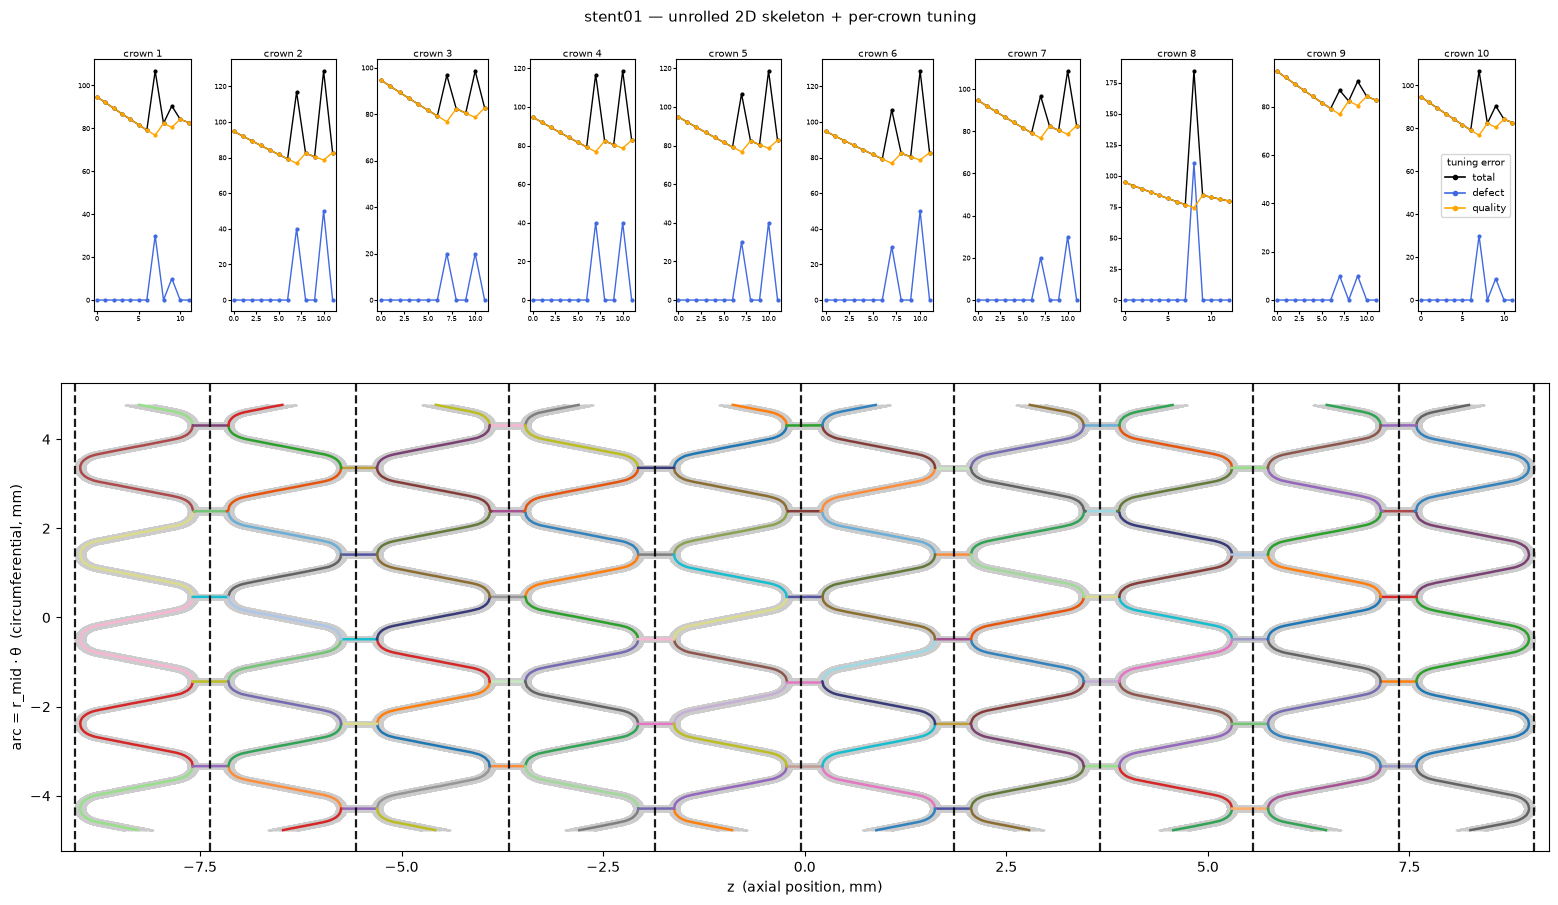

[saved] /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/examples/notebook_outputs/stent01/skeleton_splines_2d.png  (135 curves, 11 crown boundaries, 10/10 crown tuning plots)
[saved] /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/examples/notebook_outputs/stent01/skeleton_splines_2d.html
[saved] /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/examples/notebook_outputs/stent01/skeleton_splines_trimesh.html
[saved] /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/examples/notebook_outputs/stent01/skeleton_splines.glb  (135 spline curves)


In [22]:
state = finalize_skeleton(state)

## Mesh the skeleton into 1D beams (BeamMe)

`mesh_skeleton_beams(OUTPUT_DIR)` rebuilds each Step-7 spline as a `splinepy.BSpline`
and meshes it into a 1D Simo-Reissner beam mesh with BeamMe (the stent side of the
beam-to-solid contact). This needs the optional `beamme` / `splinepy` dependencies and
reads `OUTPUT_DIR/*.json`, so it also runs on a fresh kernel after the config + imports
cells. Material + element choices are provisional; only the geometry is final.

In [9]:
beam_mesh = mesh_skeleton_beams(OUTPUT_DIR)

[folder] read stent_features.json from /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/examples/notebook_outputs/stent04
[folder] strut_thickness = 0.1134 mm

Meshed 189/189 curves (0 skipped) into a 1D beam mesh:
  12,015 nodes, 5,913 Beam3rHerm2Line3 elements
  cross-section radius 0.0567 mm, target element length 0.1000 mm
[saved] /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/examples/notebook_outputs/stent04/skeleton_beam_mesh_beam.vtu
